# ENVS 117 Exercise 1: Setting Up Your Python Toolkit

**Name:** *(EmmaYang)*

**Today's goals**
1. Confirm that Python and Anaconda are working on your computer.
2. Learn how Jupyter notebooks work: cells, Markdown, and execution order.
3. Run the *same* notebook in JupyterLab and in Google Colab and compare.
4. Save your work to GitHub.

**How to run a cell:** click inside it and press `Shift + Enter`.

## Part 1. Where am I running?

Run the cell below. Write down the output. You will run this same cell again in Google Colab later and compare.

In [10]:
import sys
import os
import platform

in_colab = "google.colab" in sys.modules

print("Running in Google Colab:", in_colab)
print("Python version:        ", platform.python_version())
print("Python executable:     ", sys.executable)
print("Operating system:      ", platform.system(), platform.release())

Running in Google Colab: False
Python version:         3.14.6
Python executable:      /opt/anaconda3/bin/python
Operating system:       Darwin 24.6.0


## Part 2. Which packages do I have?

Packages are add-ons that give Python new abilities. Anaconda and Colab both come with many packages preinstalled, but not always the same ones or the same versions.

In [2]:
import numpy as np
import pandas as pd
import matplotlib

print(f"{'numpy':<12} {np.__version__}")
print(f"{'pandas':<12} {pd.__version__}")
print(f"{'matplotlib':<12} {matplotlib.__version__}")

# geopandas is the main package we will use for vector GIS data.
# It may or may not be installed yet. Either result is fine today.
try:
    import geopandas as gpd
    print(f"{'geopandas':<12} {gpd.__version__}")
except ImportError:
    print("geopandas is NOT installed in this environment (that is OK for today)")

numpy        2.4.6
pandas       3.0.3
matplotlib   3.11.0
geopandas is NOT installed in this environment (that is OK for today)


## Part 3. Where are my files?

Every notebook has a **working directory**: the folder Python looks in when you give it a file name. Most "file not found" errors come from being in a different folder than you think.

In [3]:
print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders here:")
for item in sorted(os.listdir(".")):
    print("  ", item)

Current working directory:
/Users/emmayang/Documents/ENVS117

Files and folders here:
   .ipynb_checkpoints
   EmmaYang_ENVS117_Ex1_Toolkit.ipynb
   Week2a.ipynb


## Part 4. Markdown practice

This is a **Markdown cell**. It holds text, not code. Double-click to edit it, then press `Shift + Enter` to render it.

**Your turn:** replace the line below with one sentence about an environmental question you would like to answer with data.

*My question:* How does vegetation cover affect land surface temperature in urban areas?

## Part 5. Execution order matters

Run the next three cells **in order** (A, then B, then C). Then go back and run **cell B again**. What changed, and why?

In [ ]:
# Cell A
site_temp_c = 18

In [6]:
# Cell B
print("Doubled temperature:", site_temp_c * 2)

Doubled temperature: 50


In [5]:
# Cell C
site_temp_c = 25

**Now try this:** from the menu, choose **Kernel > Restart Kernel and Run All Cells** (in Colab: **Runtime > Restart session and run all**). Look at the output of cell B again.

*What did you notice?* When I ran Cell B again after Cell C, the output changed from 36 to 50 because the variable changed from 18 to 25. After restarting the kernel and running all cells, Cell B printed 36 again because the cells ran from top to bottom.

> Lesson: a notebook remembers what you **ran**, not what you **see** on the screen. Before you submit or share a notebook, always restart and run all cells from top to bottom.

## Part 6. A tiny environmental calculation

The rainfall numbers below are **made-up example values** for a hypothetical station with a Mediterranean climate (wet winters, dry summers), organized by water year (October to September).

Total water-year rainfall: 391 mm (15.4 in)
Wettest month: Jan


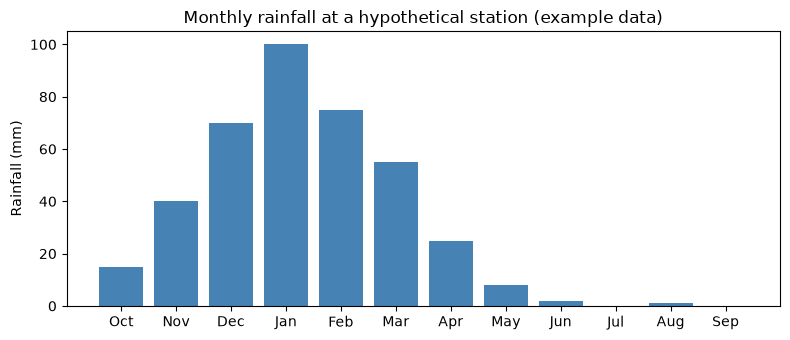

In [7]:
import matplotlib.pyplot as plt

months = ["Oct", "Nov", "Dec", "Jan", "Feb", "Mar",
          "Apr", "May", "Jun", "Jul", "Aug", "Sep"]
rain_mm = [15, 40, 70, 100, 75, 55, 25, 8, 2, 0, 1, 0]   # example values

total_mm = sum(rain_mm)
total_in = total_mm / 25.4
wettest = months[rain_mm.index(max(rain_mm))]

print(f"Total water-year rainfall: {total_mm} mm ({total_in:.1f} in)")
print(f"Wettest month: {wettest}")

plt.figure(figsize=(8, 3.5))
plt.bar(months, rain_mm, color="steelblue")
plt.ylabel("Rainfall (mm)")
plt.title("Monthly rainfall at a hypothetical station (example data)")
plt.tight_layout()
plt.show()

**Your turn:** change one or two values in `rain_mm` and re-run the cell. Does the total update? Does the chart update? Yes, both the total rainfall and the chart update when I change the rainfall values and rerun the cell.

## Part 7. Sneak peek at next week

Next week we cover variables, data types, and control flow. You do not need to understand every line yet. Just run it and guess what each line does.

In [9]:
# Example daily high temperatures (made-up values), in degrees F
site_highs_f = {"Santa Clara": 78, "Fresno": 101, "Lake Tahoe": 64}

for site, temp_f in site_highs_f.items():
    temp_c = (temp_f - 32) * 5 / 9
    if temp_c >= 35:
        label = "extreme heat"
    elif temp_c >= 25:
        label = "warm"
    else:
        label = "mild"
    print(f"{site:<12} {temp_f} F = {temp_c:.1f} C  ->  {label}")

Santa Clara  78 F = 25.6 C  ->  warm
Fresno       101 F = 38.3 C  ->  extreme heat
Lake Tahoe   64 F = 17.8 C  ->  mild


## Part 8. Reflection (answer in this cell)

1. Compare your Part 1 and Part 2 output in JupyterLab vs. Google Colab. What was different?
2. In Part 5, why did cell B print different numbers?
3. Name one situation where you would choose Colab, and one where you would choose JupyterLab.

*Your answers:* 
1. Both JupyterLab and Google Colab can run Python code. However, they use different environments, so the Python versions and installed package versions may be different.
2. Cell B printed different numbers because Cell C changed site_temp_c from 18 to 25. When I ran Cell B again, the result changed from 36 to 50. After restarting the kernel and running all cells, the result returned to 36 because the cells ran in order.
3. would choose Google Colab when working on group projects because it is easy to share notebooks and collaborate online. I would choose JupyterLab when working with GIS data stored on my computer because I can easily access and manage local files.